In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pandas import DataFrame as df

In [21]:
# pip install statsmodels --break-system-packages

Note: you may need to restart the kernel to use updated packages.


In [22]:
fig = px.scatter(all_index_dic_pct_change, x="gold", y="equal", 
                   title="黄金 vs Equal指数：每日涨跌幅散点图",
                   opacity=0.4,
                   trendline='ols')
fig.show()

由图所示,点云在中心点呈现十字状散开,表明大部分可能并没有关系.  
拟合的曲线R^2只有0.05,大部分的情况并不能正确的解释,拟合效果很弱.Pearson系数表明他的线性关系并不太明显  
而较大程度的波动的离散点似乎呈现一个微弱的正相关性,根据图中点的分布,我们把equal指数>2,gold价格>1的部分作为波动较大的点,单独找出来,查看它们的关系.

In [28]:
positive = extreme_days[((extreme_days['gold']>0 ) & (extreme_days['equal']>0))|((extreme_days['gold'] < 0) & (extreme_days['equal'] < 0))]
print(len(positive))

209


In [29]:
negative = extreme_days[
    ((extreme_days['gold'] < 0) & (extreme_days['equal'] > 0)) |
    ((extreme_days['gold'] > 0) & (extreme_days['equal'] < 0))
]
print(len(negative))

63


在筛选出我主观设定的极端情况后,两者呈现正向线性关系的可能性比较高,76.8%的情况极端情况下金价与等权黄金股票指数同涨同跌.拟合的曲线R^2达到29%,相关性提升了.  
但是黄金价格的的单位增长对应股票指数的更大浮动涨跌,可能说明股票不仅受金价等实时价格的供需关系影响,也会受消息面,资金面,情绪面等影响,因此波动更大.
也就是说,如果金价波动较大,超过了一定范围,那么整体黄金价格大概率是跟涨或跟跌,鉴于金价的期货时间价格更长,可以在开盘前根据金价的变化来决定及时抛出或者购入股票.

In [31]:
fig = px.scatter(all_index_dic_pct_change, x="gold", y="CSI_300", 
                   title="黄金 vs 沪深指数：每日涨跌幅散点图",
                   opacity=0.4,
                   trendline='ols')
fig.show()

In [ ]:
拿沪深300和金价指数来看,似乎更加找不到关系,拟合曲线近乎为0,R^2 也很低,同样分成黄金的高波动和低波动来判断

In [36]:
all_index_dic_pct_change['gold'].describe()

count    3690.000000
mean        0.030728
std         1.043727
min       -11.366201
25%        -0.439397
50%         0.008617
75%         0.547323
max         6.083292
Name: gold, dtype: float64

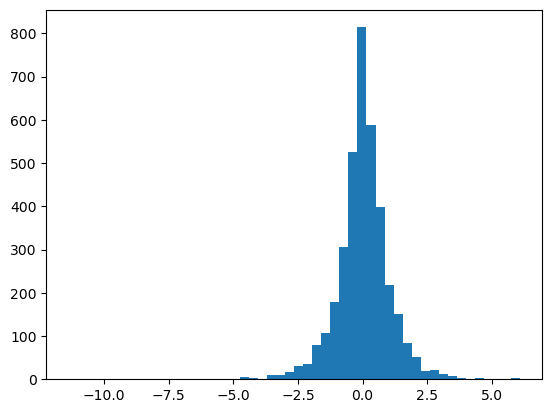

In [33]:
plt.hist(all_index_dic_pct_change["gold"], bins=50)
plt.show()

In [38]:
all_index_dic_pct_change['gold'].quantile([0.05, 0.1, 0.25, 0.75, 0.9, 0.95])

0.05   -1.620972
0.10   -1.102164
0.25   -0.439397
0.75    0.547323
0.90    1.172255
0.95    1.630588
Name: gold, dtype: float64

我们在此处取abs(1.62)作为极端值的判断,90%的数值都在(-1.62,1.62)的范围内

In [42]:
normal_days = all_index_dic_pct_change[abs(all_index_dic_pct_change['gold'])<=1.62]
extreme_days =all_index_dic_pct_change[~(abs(all_index_dic_pct_change['gold'])<=1.62)]

In [43]:
fig = px.scatter(normal_days, x="gold", y="CSI_300", 
                   title="黄金 vs 沪深指数：正常情况涨跌幅散点图",
                   opacity=0.4,
                   trendline='ols')
fig.show()

可以说,金价和指数在正常情况下几乎毫无关系

In [44]:
fig = px.scatter(extreme_days, x="gold", y="CSI_300", 
                   title="黄金 vs 沪深指数：极端情况涨跌幅散点图",
                   opacity=0.4,
                   trendline='ols')
fig.show()

即使在极端情况下,金价的大涨和指数也只能呈现微弱的关系.
### 可能的原因:  
1.可能是由于通胀的原因,某种程度上会推高股票的价格和金价.  
2.亦或者是情绪高涨,钱流入了黄金和股票.

In [115]:
# import akshare as ak
cpi = ak.macro_china_cpi()
# cpi = cpi.sort_index(ascending=False)
display(cpi)

,月份,全国-当月,全国-同比增长,全国-环比增长,全国-累计,城市-当月,城市-同比增长,城市-环比增长,城市-累计,农村-当月,农村-同比增长,农村-环比增长,农村-累计
0,2026年06月份,101.0000,1.0000,-0.3000,101.0000,101.0000,1.0000,-0.4,101.0000,100.8000,0.8000,-0.3,100.8000
1,2026年05月份,101.2000,1.2000,-0.1000,101.0000,101.3000,1.3000,-0.1,101.0000,101.1000,1.1000,-0.1,100.8000
2,2026年04月份,101.2000,1.2000,0.3000,100.9000,101.2000,1.2000,0.3,101.0000,101.0000,1.0000,0.1,100.7000
3,2026年03月份,101.0000,1.0000,-0.7000,100.9000,101.1000,1.1000,-0.7,100.9000,100.9000,0.9000,-0.5,100.7000
4,2026年02月份,101.3000,1.3000,1.0000,100.8000,101.4000,1.4000,1.0,100.8000,100.9000,0.9000,0.7,100.5000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
217,2008年05月份,107.7163,7.7163,-0.4000,108.0666,107.3331,7.3331,-0.5,107.7393,108.5481,8.5481,-0.3,108.7612
218,2008年04月份,108.4829,8.4829,0.1038,108.1544,108.1094,8.1094,0.1,107.8412,109.2737,9.2737,0.1,108.8147
219,2008年03月份,108.3097,8.3097,-0.7000,108.0449,107.9699,7.9699,-0.8,107.7517,109.0330,9.0330,-0.5,108.6618
220,2008年02月份,108.7443,8.7443,2.6000,107.9154,108.4973,8.4973,2.7,107.6418,109.2344,9.2344,2.4,108.4812


In [116]:
cpi = cpi[['全国-当月','月份']]
cpi['月份'] = pd.to_datetime(cpi['月份'],format='%Y年%m月份')
cpi = cpi.set_index('月份')
cpi = cpi[cpi.index >= '2012-05-01']
display(cpi)

/var/folders/nm/mph7gkl57w5_rd8w9fgp9c5r0000gp/T/ipykernel_21723/3984824246.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,全国-当月
月份,
2026-06-01,101.0000
2026-05-01,101.2000
2026-04-01,101.2000
2026-03-01,101.0000
2026-02-01,101.3000
...,...
2012-09-01,101.9000
2012-08-01,102.0000
2012-07-01,101.8000


In [117]:
cpi = cpi.sort_index(ascending=True)
display(cpi)

,全国-当月
月份,
2012-05-01,103.0008
2012-06-01,102.1504
2012-07-01,101.8000
2012-08-01,102.0000
2012-09-01,101.9000
...,...
2026-02-01,101.3000
2026-03-01,101.0000
2026-04-01,101.2000


In [118]:
#我要查看的是cpi的百分比
cpi = cpi -100

In [121]:
# cpi = cpi.round(4)
cpi.describe()

,全国-当月
count,170.000000
mean,1.586742
std,1.128731
min,-0.800000
25%,0.800000
50%,1.700000
75%,2.300000
max,5.400000


由于金价与指数的数据是每一日都有,所以说我应该根据月把这些CPI赋给它们

In [102]:
gold = all_index_dic['gold']
display(gold)

2012-05-09    1000.000000
2012-05-10    1000.878474
2012-05-11     993.662561
2012-05-14     979.230736
2012-05-15     976.846393
                 ...     
2026-07-20    2516.345719
2026-07-21    2554.495967
2026-07-22    2602.058122
2026-07-23    2539.122935
2026-07-24            NaN
Name: gold, Length: 3690, dtype: float64

In [84]:
gold['CPI_period'] = gold.index.to_period("M")

In [85]:

gold['cpi'] = gold['CPI_period'].map(cpi['全国-当月'])
display(gold)

2012-05-09 00:00:00                                               1000.0
2012-05-10 00:00:00                                          1000.878474
2012-05-11 00:00:00                                           993.662561
2012-05-14 00:00:00                                           979.230736
2012-05-15 00:00:00                                           976.846393
                                             ...                        
2026-07-22 00:00:00                                          2602.058122
2026-07-23 00:00:00                                          2539.122935
2026-07-24 00:00:00                                                  NaN
CPI_period             PeriodIndex(['2012-05', '2012-05', '2012-05', ...
cpi                    Index([nan, nan, nan, nan, nan, nan, nan, nan,...
Name: gold, Length: 3692, dtype: object

这里添加新的列失败,因为之前Gold变量是一个Series,用[]添加一列的尝试其实是添加一个新的项目.因此要把Series转换成Dataframe

In [103]:
gold = all_index_dic['gold']
gold = gold.to_frame()
display(gold)

,gold
2012-05-09,1000.000000
2012-05-10,1000.878474
2012-05-11,993.662561
2012-05-14,979.230736
2012-05-15,976.846393
...,...
2026-07-20,2516.345719
2026-07-21,2554.495967
2026-07-22,2602.058122
2026-07-23,2539.122935


In [128]:
gold['CPI_period'] = gold.index.to_period('M')


In [129]:
gold['cpi'] = gold['CPI_period'].map(cpi['全国-当月'])
display(gold)

,gold,cpi,CPI_period
2012-05-09,1000.000000,3.0008,2012-05
2012-05-10,1000.878474,3.0008,2012-05
2012-05-11,993.662561,3.0008,2012-05
2012-05-14,979.230736,3.0008,2012-05
2012-05-15,976.846393,3.0008,2012-05
...,...,...,...
2026-07-20,2516.345719,NaN,2026-07
2026-07-21,2554.495967,NaN,2026-07
2026-07-22,2602.058122,NaN,2026-07
2026-07-23,2539.122935,NaN,2026-07


因为CPI的index是datatime类型,而CPI_period是Period类型,因此格式不一致无法映射匹配.

In [125]:
# cpi.index = cpi.index.to_period()
# gold['cpi'] = gold['CPI_period'].map(cpi['全国-当月'])


KeyError: 'CPI_period'

In [130]:
# gold = gold.drop('CPI_period',axis=1)
# gold['cpi'] = ((gold['cpi']-1)100).round(2)

display(gold)

,gold,cpi,CPI_period
2012-05-09,1000.000000,3.0008,2012-05
2012-05-10,1000.878474,3.0008,2012-05
2012-05-11,993.662561,3.0008,2012-05
2012-05-14,979.230736,3.0008,2012-05
2012-05-15,976.846393,3.0008,2012-05
...,...,...,...
2026-07-20,2516.345719,NaN,2026-07
2026-07-21,2554.495967,NaN,2026-07
2026-07-22,2602.058122,NaN,2026-07
2026-07-23,2539.122935,NaN,2026-07


In [133]:
CSI_300 = all_index_dic_pct_change['CSI_300']
CSI_300 = CSI_300.to_frame()
CSI_300['CPI_period'] = CSI_300.index.to_period('M')
display(CSI_300)

,CSI_300,CPI_period
2012-05-09,0.000000,2012-05
2012-05-10,-0.011289,2012-05
2012-05-11,-0.763845,2012-05
2012-05-14,-0.810909,2012-05
2012-05-15,0.070349,2012-05
...,...,...
2026-07-20,1.528473,2026-07
2026-07-21,3.064336,2026-07
2026-07-22,-0.463894,2026-07
2026-07-23,0.228057,2026-07


In [135]:
CSI_300['cpi'] = CSI_300['CPI_period'].map(cpi['全国-当月'])
display(CSI_300)

,CSI_300,CPI_period,cpi
2012-05-09,0.000000,2012-05,3.0008
2012-05-10,-0.011289,2012-05,3.0008
2012-05-11,-0.763845,2012-05,3.0008
2012-05-14,-0.810909,2012-05,3.0008
2012-05-15,0.070349,2012-05,3.0008
...,...,...,...
2026-07-20,1.528473,2026-07,NaN
2026-07-21,3.064336,2026-07,NaN
2026-07-22,-0.463894,2026-07,NaN
2026-07-23,0.228057,2026-07,NaN


我们得到了CPI,用CPI作为通胀的指标.我们根据央行目标,选择通胀在3%作为温和通胀和严重通胀的分界线.我们先看看通胀和指数涨幅的关系.  
![中国央行通胀目标](../../src/pic/央行通胀目标.png)

In [137]:
fig = px.scatter(CSI_300,x='CSI_300',y='cpi')
fig.show()

从图上看,似乎看不出一个明显的规律.我基于一个经济学假设,温和的通胀是有利于股市的,高通胀和通缩不利于实体经济从而影响股市.因此我将<0 ,0-3, >3 划分成通缩,温和通胀,严重通胀,看看它们涨跌比例,平均涨跌幅度

In [139]:
extreme_inflation_CSI = CSI_300[CSI_300['cpi'] > 3]
normal_inflation_CSI = CSI_300[(CSI_300['cpi'] >= 0) & (CSI_300['cpi'] <= 3)]
negative_inflation_CSI = CSI_300[CSI_300['cpi'] < 0]

In [149]:
print('高通胀情况下,上涨天数比例为:',(extreme_inflation_CSI['CSI_300']>=0).mean(),'平均上涨幅度为:',extreme_inflation_CSI[extreme_inflation_CSI['CSI_300']>=0]['CSI_300'].mean())
print('高通胀情况下,下降天数比例为:',(extreme_inflation_CSI['CSI_300']<0).mean(),'平均下降幅度为:',extreme_inflation_CSI[extreme_inflation_CSI['CSI_300']<=0]['CSI_300'].mean())
print('高通胀情况下,平均涨跌幅为:',extreme_inflation_CSI['CSI_300'].mean())

高通胀情况下,上涨天数比例为: 0.5708154506437768 平均上涨幅度为: 0.7759360554556327
高通胀情况下,下降天数比例为: 0.4291845493562232 平均下降幅度为: -0.7812942112361859
高通胀情况下,平均涨跌幅为: 0.023767034210626335


In [150]:
print('温和通胀情况下,上涨天数比例为:', (normal_inflation_CSI['CSI_300'] >= 0).mean(), '平均上涨幅度为:', normal_inflation_CSI[normal_inflation_CSI['CSI_300'] >= 0]['CSI_300'].mean())
print('温和通胀情况下,下降天数比例为:', (normal_inflation_CSI['CSI_300'] < 0).mean(), '平均下降幅度为:', normal_inflation_CSI[normal_inflation_CSI['CSI_300'] <= 0]['CSI_300'].mean())
print('温和通胀情况下,平均涨跌幅为:', normal_inflation_CSI['CSI_300'].mean())

温和通胀情况下,上涨天数比例为: 0.5418390073178492 平均上涨幅度为: 0.8261991599797371
温和通胀情况下,下降天数比例为: 0.4581609926821508 平均下降幅度为: -0.8139007991071137
温和通胀情况下,平均涨跌幅为: 0.023754871558112383


In [151]:
print('通缩情况下,上涨天数比例为:', (negative_inflation_CSI['CSI_300'] >= 0).mean(), '平均上涨幅度为:', negative_inflation_CSI[negative_inflation_CSI['CSI_300'] >= 0]['CSI_300'].mean())
print('通缩情况下,下降天数比例为:', (negative_inflation_CSI['CSI_300'] < 0).mean(), '平均下降幅度为:', negative_inflation_CSI[negative_inflation_CSI['CSI_300'] <= 0]['CSI_300'].mean())
print('通缩情况下,平均涨跌幅为:', negative_inflation_CSI['CSI_300'].mean())

通缩情况下,上涨天数比例为: 0.5371621621621622 平均上涨幅度为: 0.7159221030065608
通缩情况下,下降天数比例为: 0.46283783783783783 平均下降幅度为: -0.6588329008989285
通缩情况下,平均涨跌幅为: 0.04624666703177716


In [154]:
print('高通胀有', len(extreme_inflation_CSI), '天')
print('温和通胀有', len(normal_inflation_CSI), '天')
print('通缩有', len(negative_inflation_CSI), '天')

高通胀有 233 天
温和通胀有 3143 天
通缩有 296 天


由于高通胀和通缩状态样本储量比较少,大概只有8-10个月,可能与特定的历史时期有关.因此得到的结论可能不能代表普遍情况.  
单纯从数字得到的结论:  
1. 高通胀环境下上涨可能性更大  
2. 通缩情况下平均涨跌幅更大  
     
     
这两个结论可能有误导性.我们先把这段历史时期找出来

In [157]:
extreme_inflation_CSI['CPI_period'].unique()

<PeriodArray>
['2012-05', '2013-02', '2013-09', '2013-10', '2019-10', '2019-11', '2019-12',
 '2020-01', '2020-02', '2020-03', '2020-04']
Length: 11, dtype: period[M]

In [158]:
negative_inflation_CSI['CPI_period'].unique()

<PeriodArray>
['2020-11', '2021-01', '2021-02', '2023-07', '2023-10', '2023-11', '2023-12',
 '2024-01', '2025-02', '2025-03', '2025-04', '2025-05', '2025-08', '2025-09']
Length: 14, dtype: period[M]

现在先进行卡方独立性检验,我的零假设是通胀和股价无关,备择假设是通胀和股价有关

In [159]:
from scipy.stats import chi2_contingency

In [161]:
table = pd.DataFrame({
    "上涨天数": [
        (extreme_inflation_CSI["CSI_300"] >= 0).sum(),
        (normal_inflation_CSI["CSI_300"] >= 0).sum(),
        (negative_inflation_CSI["CSI_300"] >= 0).sum(),
    ],
    "下跌天数": [
        (extreme_inflation_CSI["CSI_300"] < 0).sum(),
        (normal_inflation_CSI["CSI_300"] < 0).sum(),
        (negative_inflation_CSI["CSI_300"] < 0).sum(),
    ]
}, index=["高通胀", "温和通胀", "通缩"])

print(table)

      上涨天数  下跌天数
高通胀    133   100
温和通胀  1703  1440
通缩     159   137


In [162]:
chi2, p, dof, expected = chi2_contingency(table)
print(f"卡方值: {chi2:.4f}, p值: {p:.4f}")

卡方值: 0.7829, p值: 0.6761


由于P值显著大于0.05,不能选择备择假设,认为通胀和股市涨跌幅有显著关系.

In [165]:
gold['pct_change'] = all_index_dic_pct_change['gold']
display(gold)


,gold,cpi,CPI_period,pct_change
2012-05-09,1000.000000,3.0008,2012-05,0.000000
2012-05-10,1000.878474,3.0008,2012-05,0.087847
2012-05-11,993.662561,3.0008,2012-05,-0.720958
2012-05-14,979.230736,3.0008,2012-05,-1.452387
2012-05-15,976.846393,3.0008,2012-05,-0.243491
...,...,...,...,...
2026-07-20,2516.345719,NaN,2026-07,-0.059808
2026-07-21,2554.495967,NaN,2026-07,1.516097
2026-07-22,2602.058122,NaN,2026-07,1.861900
2026-07-23,2539.122935,NaN,2026-07,-2.418670


In [166]:
fig = px.scatter(gold,x='pct_change',y='cpi')
fig.show()

In [169]:
extreme_inflation_gold = gold[gold['cpi'] > 3]
normal_inflation_gold = gold[(gold['cpi'] >= 0) & (gold['cpi'] <= 3)]
negative_inflation_gold = gold[gold['cpi'] < 0]

In [171]:
print('高通胀情况下,上涨天数比例为:',(extreme_inflation_gold['pct_change']>=0).mean(),'平均上涨幅度为:',extreme_inflation_gold[extreme_inflation_gold['pct_change']>=0]['pct_change'].mean())
print('高通胀情况下,下降天数比例为:',(extreme_inflation_gold['pct_change']<0).mean(),'平均下降幅度为:',extreme_inflation_gold[extreme_inflation_gold['pct_change']<=0]['pct_change'].mean())
print('高通胀情况下,平均涨跌幅为:',extreme_inflation_gold['pct_change'].mean())

高通胀情况下,上涨天数比例为: 0.5150214592274678 平均上涨幅度为: 0.8616943842664428
高通胀情况下,下降天数比例为: 0.48497854077253216 平均下降幅度为: -0.7928562527708413
高通胀情况下,平均涨跌幅为: 0.01503621572037404


In [172]:
print('温和通胀情况下,上涨天数比例为:', (normal_inflation_gold['pct_change'] >= 0).mean(), '平均上涨幅度为:', normal_inflation_gold[normal_inflation_gold['pct_change'] >= 0]['pct_change'].mean())
print('温和通胀情况下,下降天数比例为:', (normal_inflation_gold['pct_change'] < 0).mean(), '平均下降幅度为:', normal_inflation_gold[normal_inflation_gold['pct_change'] <= 0]['pct_change'].mean())
print('温和通胀情况下,平均涨跌幅为:', normal_inflation_gold['pct_change'].mean())

温和通胀情况下,上涨天数比例为: 0.5377028316894686 平均上涨幅度为: 0.6647159559841013
温和通胀情况下,下降天数比例为: 0.46229716831053136 平均下降幅度为: -0.6692596741091378
温和通胀情况下,平均涨跌幅为: 0.024812712266833563


In [173]:
print('通缩情况下,上涨天数比例为:', (negative_inflation_gold['pct_change'] >= 0).mean(), '平均上涨幅度为:', negative_inflation_gold[negative_inflation_gold['pct_change'] >= 0]['pct_change'].mean())
print('通缩情况下,下降天数比例为:', (negative_inflation_gold['pct_change'] < 0).mean(), '平均下降幅度为:', negative_inflation_gold[negative_inflation_gold['pct_change'] <= 0]['pct_change'].mean())
print('通缩情况下,平均涨跌幅为:', negative_inflation_gold['pct_change'].mean())

通缩情况下,上涨天数比例为: 0.5743243243243243 平均上涨幅度为: 0.8025540713765087
通缩情况下,下降天数比例为: 0.42567567567567566 平均下降幅度为: -0.7742079191019325
通缩情况下,平均涨跌幅为: 0.10520917275724213


为什么会出现这样的情况?理论上一般高通胀会推动黄金价格上涨,但是在处理的结果上,通缩状态下上涨的天数,平均的涨幅反而更大.  
可能是样本量较小,集中在某些特定的日子,经过箱型图查看,通缩期间的数据,中位数高于温和通胀的数据,得到的数据没有问题.  
而实际上,金价的涨跌一般被认为是实际利率,需要参考美国的10年国债收益率,减去通胀水平进行判断.

<Axes: ylabel='pct_change'>

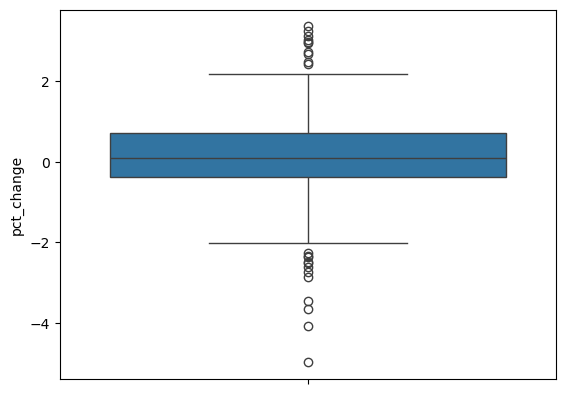

In [174]:
sns.boxplot(negative_inflation_gold['pct_change'])

<Axes: ylabel='pct_change'>

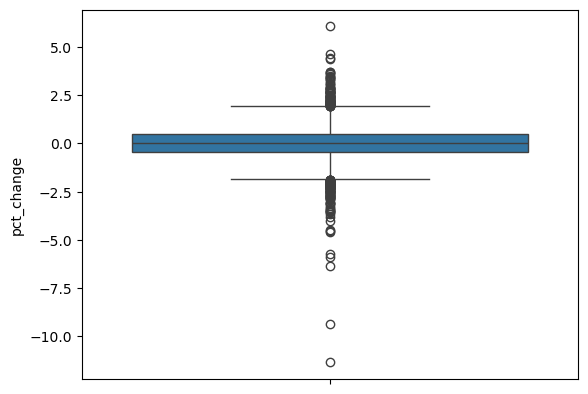

In [175]:
sns.boxplot(normal_inflation_gold['pct_change'])

In [177]:
table = pd.DataFrame({
    "上涨天数": [
        (extreme_inflation_gold["pct_change"] >= 0).sum(),
        (normal_inflation_gold["pct_change"] >= 0).sum(),
        (negative_inflation_gold["pct_change"] >= 0).sum(),
    ],
    "下跌天数": [
        (extreme_inflation_gold["pct_change"] < 0).sum(),
        (normal_inflation_gold["pct_change"] < 0).sum(),
        (negative_inflation_gold["pct_change"] < 0).sum(),
    ]
}, index=["高通胀", "温和通胀", "通缩"])

print(table)

chi2, p, dof, expected = chi2_contingency(table)
print(f"卡方值: {chi2:.4f}, p值: {p:.4f}")

      上涨天数  下跌天数
高通胀    120   113
温和通胀  1690  1453
通缩     170   126
卡方值: 2.0463, p值: 0.3595


由于P值显著大于0.05,不能选择备择假设,认为通胀和黄金涨跌幅有显著关系.

---   
综合以上探讨,得出此处统计结论:  

1. 股票高通胀环境下上涨可能性更大  
2. 黄金和股票通缩情况下平均涨跌幅更大  
3. 样本较小,统计时间在8-10个月,且时间上非连续,需要找出不同时段的发生大事进行探讨.

下面需要去找出时间,分别解释通胀和通缩期间发生了什么事  
  
  
---

In [179]:
extreme_inflation_CSI['CPI_period'].unique()

<PeriodArray>
['2012-05', '2013-02', '2013-09', '2013-10', '2019-10', '2019-11', '2019-12',
 '2020-01', '2020-02', '2020-03', '2020-04']
Length: 11, dtype: period[M]

经过搜索资料,查证2019年10月-2020年4月,正好是非洲猪瘟爆发导致的猪肉价格冲击导致CPI结构性上涨,食品价格上涨9.2所致,又叠加了新冠疫情,阅读20年的新闻,发现在2020年2月14日金价收于1586.4美元/盎司,是由于避险需求所致.经过前面的卡方检验,CPI高与股市上涨应该是独立的,因为在这段时间是结构性通胀而非需求拉动型通胀,结论符合现实情况.

查了一下2012年的工作报告,政府把通胀控制在4%的水平,5月正好是同比上涨3.0%,后面6月以后则CPI则偏低.符合实际情况  
2013-02主要是当年的春节在2月,2012年的在1月,因此同比的价格偏高,达到了3.2%,呈季节性特征,可以忽略.
2013-09受食品价格,国庆中秋季节性影响,水电,房租等服务性上涨影响,是正常市场扰动.  
  
综上所述,高通胀环境并不一定能推论出股票的上涨可能性较大,可能只是统计上的巧合,此外还需要叠加当时牛熊的背景  
进一步溯源发现，样本中2019年10月至2020年4月这段高通胀窗口，恰好与2019-2021年A股牛市周期的启动阶段重叠（沪深300指数2019年全年涨幅达36.07%，主因是外资流入和风险偏好回升）。这表明该时段股市的强势表现，更可能由牛市周期本身驱动，而非CPI水平的直接影响，CPI（受猪肉供给冲击推高）与股市表现在此窗口期的同步，属于两个独立驱动因素的时间重叠，而非因果关系。  
2019年1月-2021年1月 两年的消费+科技主线,可能是股票指数整体上涨的核心原因.白酒等消费股票因机构抱团行情,流动性宽裕等因素,价格翻倍,推动指数走高.


### 结论:
    得到的高通胀导致的股票价格上涨可能大,可能是叠加了不同因素共同导致的结果,并非是经济过热导致的股票价格牛市:  
    1.可能是季节性,或者外部事件冲击导致的消费价格上升,导致的结构性通胀,占据比例较小,可能存在噪音影响.  
    2.2019-2021牛市作用,疫情与非洲猪瘟正好落在这一段时间内,导致股票价格普涨,带动指数被动上涨.
    3.流动性高,外资,政府放水流入股市,基金抱团进入股市,推动了指数提高.
    

In [180]:
negative_inflation_CSI['CPI_period'].unique()

<PeriodArray>
['2020-11', '2021-01', '2021-02', '2023-07', '2023-10', '2023-11', '2023-12',
 '2024-01', '2025-02', '2025-03', '2025-04', '2025-05', '2025-08', '2025-09']
Length: 14, dtype: period[M]

21年及之前的数据,是由于非洲猪瘟爆发后价格回落,相对于之前的基数有所下调导致的.  
2023年以后,由于中国采用了封城政策,经济整体停滞,有效需求不足,查询数据,25年多年出现了CPI同比增长0.1%或者负数的情况.直到25年10月后才出现了CPI转正,可能也是由于去年基数的影响.这段时间的通缩,反映了有效需求的不足.  


### 结论:  
1. 结合一下黄金价格走势的变化,2012年-2019年间,黄金的价格几乎没有明显的变化,且2012年和2019年价格几乎持平,中间的时间价格经历下跌后又再次回升.从2019年到2026年年初,走出了黄金的一波大牛市,可能与通胀,美元体系松动,国际局势紧张影响相关.黄金的牛市正好叠加上了中国通缩,导致了一个错误的结论.
2. 20-21年,25年是中国股票市场的牛市,23-24年是中国股票市场的熊市.结合样本的数量,结论是上涨的月份比下跌的月份多,因此自然会出现平均涨跌幅偏高的情况.

# 总结:  
在提出关系,找出问题的时候,最好对历史数据进行分时段研究.要综合考虑到当时的时代背景,否则选取一段时间,只以指标来判断,可能会忽略了其他的因素得出一个错误的结论.  
在验证自己结论的时候,尽量让数据集足够大,用卡方独立性进行判断.